In [1]:
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord
import astropy.units as u
import time
import lightkurve as lk

tessBJD=BJD - 2457000

In [4]:
import lightkurve as lk
import astroquery

print(lk.__version__)
print(astroquery.__version__)

2.3.0
0.4.6


In [6]:
search_result = lk.search_lightcurve('TOI-3235', mission='TESS')
#search_result = lk.search_lightcurve('TOI-6478', mission='TESS', author='SPOC')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 11,2019,TESS-SPOC,1800,243641947,0.0
1,TESS Sector 11,2019,QLP,1800,243641947,0.0
2,TESS Sector 11,2019,GSFC-ELEANOR-LITE,1800,243641947,0.0
3,TESS Sector 11,2019,TGLC,1800,243641947,0.0
4,TESS Sector 11,2019,TARS,1800,243641947,0.0
5,TESS Sector 38,2021,TESS-SPOC,600,243641947,0.0
6,TESS Sector 38,2021,QLP,600,243641947,0.0
7,TESS Sector 38,2021,TARS,600,243641947,0.0
8,TESS Sector 64,2023,SPOC,120,243641947,0.0


TARSってやつ気になるけど見れないんか
https://arxiv.org/pdf/2603.05586

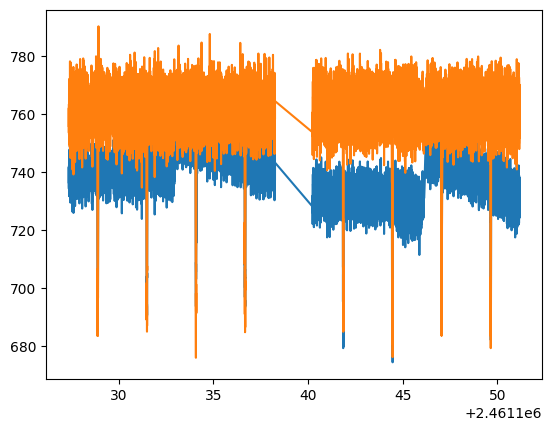

In [7]:
lc = search_result[16].download()
lc = lc.remove_nans()


time = lc.time.value + 2457000.0
sap =  lc.sap_flux.value
pdcsap = lc.pdcsap_flux.value

sap_norm = sap/np.median(sap)
pdcsap_norm = pdcsap/np.median(pdcsap)

sap_err = lc.sap_flux_err.value/np.median(sap)
pdcsap_err = lc.pdcsap_flux_err.value/np.median(pdcsap)

pl.plot(time, sap)
pl.plot(time, pdcsap)

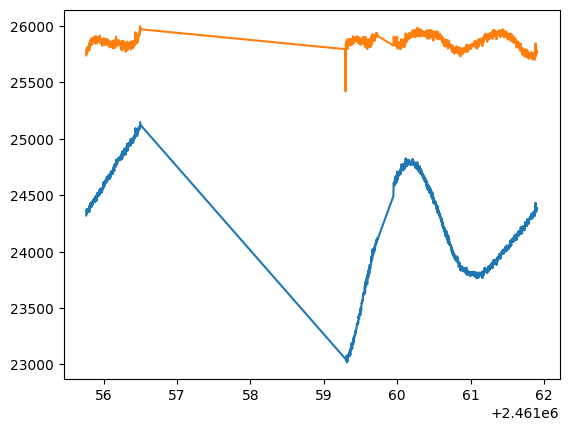

In [7]:
lc = search_result[10].download()
lc = lc.remove_nans()


time = lc.time.value + 2457000.0
sap =  lc.sap_flux.value
pdcsap = lc.pdcsap_flux.value

sap_norm = sap/np.median(sap)
pdcsap_norm = pdcsap/np.median(pdcsap)

sap_err = lc.sap_flux_err.value/np.median(sap)
pdcsap_err = lc.pdcsap_flux_err.value/np.median(pdcsap)

pl.plot(time, sap)
pl.plot(time, pdcsap)

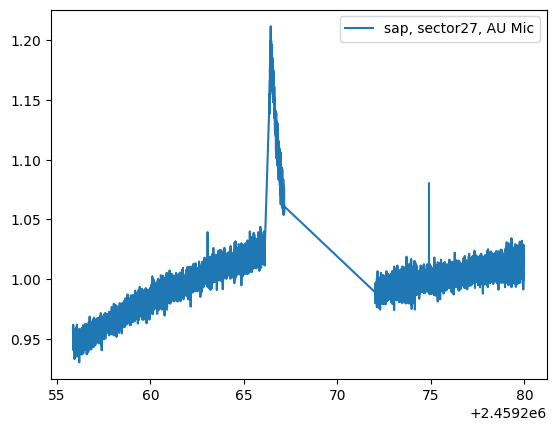

In [6]:

time = lc.time.value + 2457000.0
sap =  lc.sap_flux.value
pdcsap = lc.pdcsap_flux.value

sap_norm = sap/np.median(sap)
pdcsap_norm = pdcsap/np.median(pdcsap)

sap_err = lc.sap_flux_err.value/np.median(sap)
pdcsap_err = lc.pdcsap_flux_err.value/np.median(pdcsap)

#pl.plot(time, sap/np.median(sap), label='sap, sector63, TW Hydrae')
pl.plot(time, sap/np.median(sap), label='sap, sector27, AU Mic')
pl.legend()
#pl.plot(time, pdcsap)

5205多分stellar activity大きいね

https://arxiv.org/pdf/2502.06966